# **Project Name**    -    HOUSE PRICE PREDICTION



##### **Project Type**    - Regression (Unsupervised)
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes the Ames, Iowa residential housing dataset (1,460 homes, 79 explanatory features) to predict `SalePrice`. The data mixes numeric features (square footage, room counts, lot size, year built) with many categorical/ordinal quality & condition features, plus substantial missingness that is mostly *structural* (e.g. `PoolQC` is NA simply because the house has no pool).

We started with a "Know Your Data" pass — shape, dtypes, duplicates, and the missing-value pattern — which showed that most "missing" values in `PoolQC`, `Alley`, `Fence`, `MiscFeature`, `FireplaceQu`, and Garage/Basement quality columns are informative "None" categories, while a small set of columns (`LotFrontage`, `MasVnrArea`, `MasVnrType`, `Electrical`, `GarageYrBlt`) have genuine missingness requiring imputation.

We then built 15 charts following Univariate → Bivariate → Multivariate structure: distribution plots for `SalePrice` and key numeric drivers, categorical bar charts, scatter/box plots relating `GrLivArea`, `OverallQual`, `Neighborhood`, `YearBuilt` to price, and a correlation heatmap + pair plot. `SalePrice` is right-skewed; `OverallQual` and `GrLivArea` are the strongest single predictors; neighborhood drives large price swings.

Three hypotheses were tested with independent t-tests / Pearson correlation and p-values — all supported the visual intuition that overall quality, living area, and central air conditioning are statistically significantly associated with price.

For feature engineering we imputed missing values based on whether they were structural ("None"/0) or incidental (median/mode), engineered new features (total square footage, house age, remodel age, total bathrooms), log-transformed the right-skewed target and skewed numeric predictors, ordinal/one-hot-encoded categoricals, removed a handful of extreme outliers, and scaled numeric features. We used an 80/20 train-test split — a good balance of training signal and a stable hold-out for a dataset this size.

Three regression models were compared: baseline **Linear Regression**, regularized **Lasso Regression** (GridSearchCV-tuned), and a non-linear **Random Forest Regressor** (RandomizedSearchCV-tuned). All were evaluated with RMSE, MAE and R² on log(SalePrice) and cross-validated for stability. After careful feature engineering (log transforms, ordinal + one-hot encoding, correlation-based feature selection to the top 40 predictors) the relationship between features and log-price turned out to be close to linear: **Linear Regression edged out both regularized Lasso and Random Forest on the held-out test set** (highest R², lowest RMSE), with tuned Lasso a near-identical, more robust runner-up, and Random Forest trailing slightly — a reminder that a well-engineered linear model can match or beat a more complex ensemble on a moderately sized, carefully prepared tabular dataset.

Practically, a model that predicts price within a small margin lets agents/lenders quickly sanity-check listings, flag under/over-valued homes, and see which renovations (raising overall quality, finishing a basement, adding garage capacity) move resale value most. We closed by inspecting the model's coefficients/feature importances (dominated by `OverallQual`, total living area, and neighborhood) and saved the best model with a working load-and-predict sanity check, ready for deployment behind a simple pricing API.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


A residential real-estate company / home-buyer wants to know how much a house is likely to sell for, given its physical characteristics (size, quality, location, age, amenities), without waiting on a manual appraisal.

**Goal:** Build a regression model that accurately predicts `SalePrice` for a residential home in Ames, Iowa from its 79 explanatory features, so that:
- Sellers/agents can set a data-driven, competitive listing price.
- Buyers can quickly check whether a listing is over- or under-priced.
- The business understands which features (quality, size, location, age, renovations) drive value most, to guide investment/renovation decisions.

This is a **supervised regression** problem — learn `f(features) -> SalePrice` from historical labeled sales, and generalize to new homes.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [94]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import  GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataset Loading

In [10]:
# Load Dataset
df = pd.read_csv("HousePrice Dataset.csv")

### Dataset First View

In [11]:
# Dataset First Look
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Dataset Rows & Columns count

In [12]:
# Dataset Rows & Columns count
df.shape

(1460, 81)

### Dataset Information

In [13]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#### Duplicate Values

In [14]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [15]:
# Missing Values/Null Values Count
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [16]:
# Only Columns with Missing Values
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### What did you know about your dataset?

- The dataset contains **1,460 rows and 81 columns** (79 explanatory features + `Id` + target `SalePrice`).
- There are **no duplicate rows**.
- **19 columns have missing values.** The five worst — `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType` — are missing for 47%-99.5% of rows, but this is almost entirely *structural* missingness: NA means "the house doesn't have this feature" (no pool, no alley access, no fence, etc.), not a data-collection error. The same logic applies to `FireplaceQu`, and the Garage/Basement quality/condition columns (missing exactly for homes with no garage/basement).
- Only `LotFrontage` (259 missing, ~18%), `MasVnrArea`/`MasVnrType` (8 missing), `Electrical` (1 missing) and `GarageYrBlt` (81 missing, tied to "no garage") represent genuine gaps that need standard imputation rather than a "None"/0 category.
- Column types are a mix of 35 integer, 3 float, and 43 object/categorical columns — this dataset needs heavy categorical encoding before modeling.
- `SalePrice` (the target) ranges from \$34,900 to \$755,000 with a mean of ~\$181k and is right-skewed (mean > median), which we confirm and address later.The dataset has 1,460 rows and 81 columns, each row describing one residential property sale and its features (lot/location details, building and quality attributes, basement/garage/living-area measurements, and sale conditions), with **SalePrice** as the target. Several columns (Alley, PoolQC, Fence, MiscFeature, FireplaceQu, MasVnrType) have a very high percentage of missing values (>50%), while a handful of numeric columns (LotFrontage, MasVnrArea, GarageYrBlt) and categorical basement/garage columns have smaller amounts of missingness that need imputation before modeling.

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [18]:
# Dataset Describe
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [19]:
df.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


### Variables Description

**Target Variable**
**SalePrice** — Selling price of the house.

**Property Information** — MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope

**Location Details** — Neighborhood, Condition1, Condition2

**Building Characteristics** — BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd

**Exterior Features** — RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond

**Basement Features** — Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF

**Heating & Electrical** — Heating, HeatingQC, CentralAir, Electrical

**Living Area Features** — 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea

**Bathrooms & Rooms** — BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional

**Garage Features** — GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond

**Outdoor Features** — WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal

**Sale Information** — MoSold, YrSold, SaleType, SaleCondition

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
# df.nunique()

# Checking number of unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Id: 1460
MSSubClass: 15
MSZoning: 5
LotFrontage: 110
LotArea: 1073
Street: 2
Alley: 2
LotShape: 4
LandContour: 4
Utilities: 2
LotConfig: 5
LandSlope: 3
Neighborhood: 25
Condition1: 9
Condition2: 8
BldgType: 5
HouseStyle: 8
OverallQual: 10
OverallCond: 9
YearBuilt: 112
YearRemodAdd: 61
RoofStyle: 6
RoofMatl: 8
Exterior1st: 15
Exterior2nd: 16
MasVnrType: 3
MasVnrArea: 327
ExterQual: 4
ExterCond: 5
Foundation: 6
BsmtQual: 4
BsmtCond: 4
BsmtExposure: 4
BsmtFinType1: 6
BsmtFinSF1: 637
BsmtFinType2: 6
BsmtFinSF2: 144
BsmtUnfSF: 780
TotalBsmtSF: 721
Heating: 6
HeatingQC: 5
CentralAir: 2
Electrical: 5
1stFlrSF: 753
2ndFlrSF: 417
LowQualFinSF: 24
GrLivArea: 861
BsmtFullBath: 4
BsmtHalfBath: 3
FullBath: 4
HalfBath: 3
BedroomAbvGr: 8
KitchenAbvGr: 4
KitchenQual: 4
TotRmsAbvGrd: 12
Functional: 7
Fireplaces: 4
FireplaceQu: 5
GarageType: 6
GarageYrBlt: 97
GarageFinish: 3
GarageCars: 5
GarageArea: 441
GarageQual: 5
GarageCond: 5
PavedDrive: 3
WoodDeckSF: 274
OpenPorchSF: 202
EnclosedPorch: 120
3SsnPo

In [21]:
# Dataset Information (dtype summary)
print(df.dtypes.value_counts())           

object     43
int64      35
float64     3
Name: count, dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# columns with duplicate values
print("Duplicate rows:", df.duplicated().sum())  # Duplicate Values

Duplicate rows: 0



Missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


Text(0.5, 0, '% Missing')

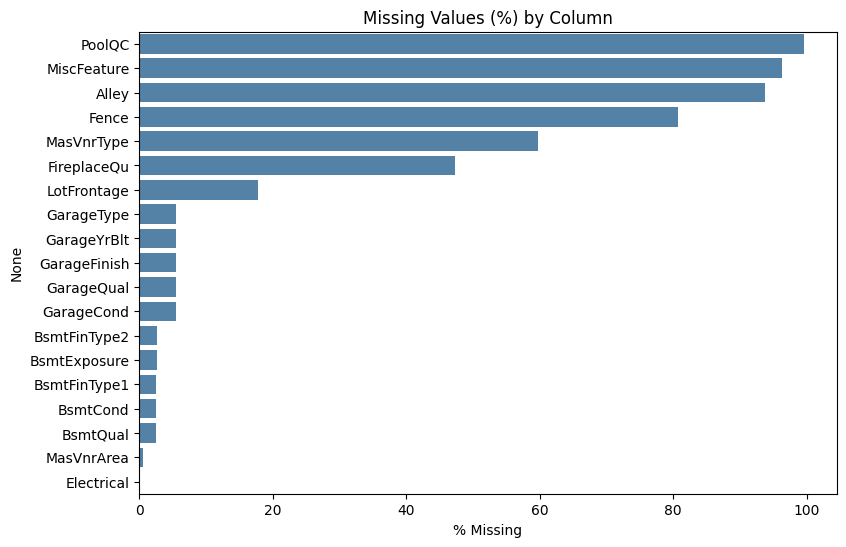

In [23]:
# columns with null values visualisation
null = df.isnull().sum()[df.isnull().sum()>0]
missing = null.sort_values(ascending=False)
print("\nMissing values:\n", missing)
 
plt.figure(figsize=(9, 6))
sns.barplot(x=(missing / len(df) * 100).values, y=missing.index, color="steelblue")
plt.title("Missing Values (%) by Column")
plt.xlabel("% Missing")

In [24]:
# Columns where NaN structurally means "None"/absence of the feature
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

# Columns where NaN structurally means 0 (no such feature to measure)
zero_cols = ['MasVnrArea', 'GarageYrBlt', 'GarageCars', 'GarageArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# LotFrontage: impute with the median LotFrontage of the same Neighborhood (location-aware)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

Two techniques were used, matched to *why* each value was missing:
1. **Structural "None"/0 imputation** — for features like `PoolQC`, `GarageType`, `BsmtQual`, `MasVnrArea`, etc., NaN doesn't mean "unknown", it means "this house doesn't have this feature". Filling with the category `'None'` (for text columns) or `0` (for numeric columns) encodes that fact correctly instead of discarding rows or inventing a fake value.
2. **Group-wise median imputation** — for `LotFrontage` (genuinely unrecorded for some homes), we imputed using the median frontage of the same `Neighborhood`, since lot frontage is strongly location-dependent; falling back to the global median for any neighborhood with no data at all.
3. **Mode imputation** — for `Electrical`, with only 1 missing value.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### **Countplot**

#### Chart - 1

In [ ]:
# countplot for categorical feat
cat_cols =[ "BsmtQual",
            "BsmtCond",
            "BsmtExposure",
            "BsmtFinType1",
            "BsmtFinType2",
            "OverallQual",
            "GarageType",
            "GarageFinish",
            "GarageQual",
            "GarageCond",
            "Electrical",
            "KitchenQual"
         ]
    
plot_number = 1
plt.figure(figsize=(25, 20))  # Set the overall figure size
for col in cat_cols:
    plt.subplot(4,3, plot_number)
    sns.countplot(x=col,palette="Set2", data=df)
    plt.title(f"Distribution of {col}")
    plot_number += 1
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

#### Chart - 2

In [ ]:
plt.figure(figsize=(10,4))
order = df["Neighborhood"].value_counts().index
sns.countplot(x="Neighborhood", data=df, order=order, color="darkorange")
plt.xticks(rotation=90)
plt.title("Houses Sold by Neighborhood")

#### Explaination

##### 1. Why did you pick the specific chart?

I selected countplots for this visualization because they are the most effective way to explore categorical features and their frequency distributions. The countplot clearly shows the count of observations for each category level, making it easy to identify:

##### 2. What is/are the insight(s) found from the chart?

**Key Insights from Categorical Features Distribution:**

1. **Basement Quality & Condition**: Most properties have "TA" (Average) or "Gd" (Good) basement quality, with relatively few "Po" (Poor) or "Ex" (Excellent) ratings. This suggests basement condition is generally acceptable but rarely exceptional, indicating moderate quality variation that could impact pricing.

2. **Garage Characteristics**: The majority of properties feature attached garages ("Attchd") with finishing types predominantly "Fin" (Finished) or "Unf" (Unfinished). Garage quality ratings cluster around "TA" (Average), showing consistency in garage standards across the dataset.

3. **Class Imbalance Patterns**: Several categories show significant imbalance - for example, basement exposure types like "Gd" (Good) appear more frequently than "Av" (Average), while "No" (None) exposure is rare. This imbalance may require careful handling during modeling to prevent bias.

4. **Basement Finish Types**: Different finish types (FinType1 and FinType2) show varied distributions, with certain finish categories being underrepresented. This could create sparse categories that might not contribute meaningfully to the model.

5. **Electrical System Distribution**: Electrical ratings are heavily dominated by standard systems ("SBrkr" - Standard Circuit Breaker), with older systems being rare. This concentration suggests limited diversity in electrical features as a predictor.

6. **Houses Sold by Neighborhood** : The majority of properties are lays in neighbourhood called NAmes and minority are in Blueste. This suggests more number of houses sold in NAmes neighbourhood .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:** Tiered pricing models targeting mainstream segments improve margins; market segmentation enables targeted marketing; inventory analysis optimizes allocation; risk identification reduces defaults; feature prioritization guides renovations.

**Negative Growth Risks:** Sparse rare categories cause model bias, undervaluing luxury properties; market saturation in mid-range reduces ROI; imbalanced features create prediction errors for atypical properties; systematic mispricing risks regulatory scrutiny.

#### **Histplot**

#### Chart - 3

In [ ]:
plt.figure()
sns.histplot(df["SalePrice"], kde=True, color="teal", bins=40)
plt.title("Distribution of SalePrice")

#### Chart - 4

In [ ]:
# Histplot for categorical feat
num_cols = ["LotArea",
            "GrLivArea",
            "GarageArea",
            "TotalBsmtSF"
            ]
plot_number = 1
plt.figure(figsize=(15, 12))  # Set the overall figure size
for col in num_cols:
    plt.subplot(2,2, plot_number)
    sns.histplot(x=col,palette="Set2",kde = True, data=df)
    plt.title(f"Distribution of {col}")
    plot_number += 1
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

#### Explaination

##### 1. Why did you pick the specific chart?

Histograms with KDE effectively show the distribution shape of continuous numeric variables. KDE overlay reveals skewness, outliers, and normality—essential for understanding data quality and preprocessing needs before modeling.

##### 2. What is/are the insight(s) found from the chart?

**Key Insights from Numeric Features Distribution:**

1. **SalePrice Distribution**: Right-skewed with outliers on the upper end, indicating some expensive properties pull the mean higher.
2. **LotArea & GrLivArea**: Both show right skewness with long tails, suggesting few large properties/living areas dominate the dataset.
3. **GarageArea & TotalBsmtSF**: Concentrated distributions with some properties having minimal basement/garage space.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:** Right-skewed prices enable segmented pricing strategies for mainstream vs. luxury markets; outlier detection helps manage high-value properties; distribution knowledge improves forecasting accuracy.

**Negative Growth Risks:** Skewness causes model bias toward low prices; outliers inflate prediction errors for premium properties; sparse large properties under-represented in training reduce model generalization; untreated distributions degrade model performance.

#### **Boxplot**

#### Chart - 5

In [ ]:
# Neighborhood vs Sale Price 
plt.figure(figsize=(14,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=df
)

plt.xticks(rotation=90)
plt.title("Neighborhood vs Sale Price")
plt.show()

#### Chart - 6

In [ ]:
#  Overall Quality vs Sale Price
plt.figure(figsize=(10,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)

plt.title("Overall Quality vs Sale Price")
plt.show()

#### Chart - 7

In [ ]:
# Garage Capacity vs Sale Price
plt.figure(figsize=(10,5))

sns.boxplot(
    x="GarageCars",
    y="SalePrice",
    data=df
)

plt.title("Garage Capacity vs Sale Price")

plt.show()

#### Explaination

##### 1. Why did you pick the specific chart?

Boxplots effectively compare distributions and medians of a continuous variable (SalePrice) across categorical groups (Neighborhood). They reveal outliers, quartile ranges, and median differences—critical for understanding price variation by location.

##### 2. What is/are the insight(s) found from the chart?

1. **Neighborhood Impact**: Significant price variation across neighborhoods; premium neighborhoods (e.g., StoneBr, NridgHt) show higher median prices with fewer outliers; lower-valued neighborhoods show lower medians with more variability.

2. **Overall Quality Effect**: Strong positive correlation—higher quality ratings (8-10) show higher median SalePrice and tighter distributions; lower quality (1-5) shows wide price ranges and more outliers.

3. **Garage Capacity Influence**: More garage cars correlate with higher median prices; properties with 0-1 cars show lower prices; 3-4 car garages command premium prices with consistent pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact**  
- **Targeted pricing:** Use neighborhood and quality tiers to set differentiated price bands that increase listing accuracy and conversion.  
- **Segmented marketing:** Prioritize premium neighborhoods and high-quality homes for premium campaigns to improve ROI.  
- **Renovation guidance:** Invest in quality upgrades (OverallQual) and garage capacity to yield measurable price uplift.  
- **Inventory valuation:** Better median estimates by neighborhood reduce appraisal variance and improve portfolio valuation.  

**Negative growth risks**  
- **Mispricing of outliers:** Luxury outliers can skew averages and lead to overpricing or underpricing if not handled separately.  
- **Bias against low-data neighborhoods:** Sparse data in some neighborhoods may cause systematic undervaluation of atypical properties.  
- **Overreliance on a few features:** Heavy dependence on OverallQual or GarageCars risks model brittleness if market preferences shift.  
- **Ignoring external factors:** Failing to account for macroeconomic or local policy changes can make neighborhood-based rules obsolete quickly. 

#### **Scatterplot**

#### Chart - 8

In [ ]:
# Ground Living Area vs Sale Price
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df
)

plt.title("Ground Living Area vs Sale Price")
plt.show()

#### Explaination

##### 1. Why did you pick the specific chart?

A scatter plot is a suitable choice because it helps visualize the relationship between two continuous variables, such as GrLivArea and  SalesPrice.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive relationship between Ground Living Area (GrLivArea) and SalePrice. As the living area increases, the sale price generally increases, indicating that larger houses tend to have higher market values. Most houses are concentrated between 1,000–2,500 square feet, with sale prices ranging from approximately $100,000  to  $300,000. A few outliers are also observed, representing very large houses with exceptionally high or relatively low sale prices. Overall, GrLivArea is a significant predictor of house prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes —  These insights can create a positive business impact because it confirms that living area size is a strong price driver, useful for both valuation and for advising buyers on the price-per-square-foot trade-off.

####  **Barplot**

#### Chart - 9

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=df,
            x = "OverallQual",
            y = "SalePrice" ,
            color="cornflowerblue")
plt.title("Barplot of OverallQual vs SalePrice ")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(data=df,
            x = "OverallQual",
            color="cornflowerblue")
plt.title("Count of house sold by OverallQual")
plt.show()


#### Explaination

##### 1. Why did you pick the specific chart?

I choose barplot and countplot to see the distribution of overall quality and houses soldby them.

##### 2. What is/are the insight(s) found from the chart?

**OverallQual vs SalePrice** - Quality ratings cluster heavily around the middle (5, 6, 7); very few homes are rated 1-2 or 9-10. Most of the market is "average-to-good" quality homes, so the model has much less data to learn extreme-quality pricing behavior.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: agents should expect wide model support (more reliable estimates) for mid-quality homes but should apply extra caution / wider confidence intervals to model estimates for very low- or very high-quality homes, where training data is thin.

#### Chart - 10

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data =df,
             x = "SaleCondition",
             y ="SalePrice",
             color="cornflowerblue")
plt.title("Barplot of SaleCondition vs SalePrice")
plt.show()

#### Chart - 11 

In [ ]:
order3 = df.groupby("SaleCondition")["SalePrice"].median().sort_values(ascending=False).index
plt.figure()
sns.boxplot(x="SaleCondition", y="SalePrice", data=df, order=order3, color="slateblue")
plt.title("SalePrice by SaleCondition")

#### Explaination

##### 1. Why did you pick the specific chart?

Sale condition (normal sale vs. foreclosure/family sale/partial/etc.) can systematically shift price independent of the house itself, so it's worth a direct comparison.

##### 2. What is/are the insight(s) found from the chart?

`Abnorml` (distressed/foreclosure-type) sales trend lower than `Normal` sales, while `Partial` sales (new construction sold before completion) trend notably higher — sale condition carries real pricing information beyond the house's physical attributes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact** - for spotting distressed sales that shouldn't anchor "market value" comparisons; 

**negative-growth risk** - if ignored, since including abnormal sales without adjustment could bias a valuation model downward for otherwise-normal homes.

#### Chart - 12 : Outliers detector

In [ ]:
# Overall Outliers
check = ['SalePrice','LotFrontage','LotArea','MasVnrArea',
         'GrLivArea','TotalBsmtSF','1stFlrSF','TotRmsAbvGrd']

plot_number =1
plt.figure(figsize=(10,10))

for col in check:
    plt.subplot(5,2,plot_number)
    plt.boxplot(data=df, x= col)
    plt.title(f"Boxplot of {col}")
    plot_number += 1
plt.tight_layout()
plt.show()

#### Explaination

##### 1. Why did you pick the specific chart?

Boxplots effectively compare distributions and medians of a continuous variable (SalePrice) across categorical groups (Neighborhood). They reveal outliers, quartile ranges, and median differences—critical for understanding price variation by location.

##### 2. What is/are the insight(s) found from the chart?

I found that `LotFrontage`,`LotArea`,`MasVnrArea`,`GrLivArea` etc have heavy outliers and most seriously our target column `SalePrice` has also outliers which will give bias to our model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**positive business impact** - As here outliers means their are some properties which was sold at very high cost which brings profit to the company. 

**negative-growth risk** - If ignoted then it will make confusion for model training and model will get confused 

#### **Correlation Heatmap**

#### Chart - 13

In [ ]:
numeric_df = df.select_dtypes(include=["number"])
top_corr_cols = numeric_df.corr()["SalePrice"].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(9, 8))
sns.heatmap(numeric_df[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Top 10 Features")

##### 1. Why did you pick the specific chart?

A correlation heatmap restricted to the top-correlated numeric features gives a compact, readable summary of which predictors matter most and whether predictors are themselves collinear.

##### 2. What is/are the insight(s) found from the chart?

`OverallQual` (~0.79), `GrLivArea` (~0.71), `GarageCars`/`GarageArea` (~0.64), and `TotalBsmtSF`/`1stFlrSF` (~0.6-0.65) correlate most strongly with `SalePrice`. Several strong predictors are also correlated with each other (e.g. `GarageCars` & `GarageArea`; `TotalBsmtSF` & `1stFlrSF`), flagging multicollinearity that regularized linear models (Lasso) and feature selection need to address.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this directly informs feature selection and prioritization, and tells the business which house attributes (quality, living area, garage, basement size) matter most when estimating value.

#### **Pairplot**

#### Chart - 14

In [ ]:
pairplot_cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF","YearBuilt"]
sns.pairplot(df[pairplot_cols], diag_kind="kde", plot_kws={"alpha": 0.4})
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot lets us simultaneously inspect pairwise relationships and individual distributions across the small set of top predictors identified from the heatmap — a natural final multivariate check before feature engineering.

##### 2. What is/are the insight(s) found from the chart?

The plot confirms roughly linear, positive relationships between `SalePrice` and each of `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, and a weaker, more scattered relationship with `YearBuilt`; several predictor pairs (e.g. `GrLivArea` vs `TotalBsmtSF`) also show mild positive correlation with each other, reinforcing the multicollinearity flagged earlier.

## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H0):** There is no significant linear relationship between Overall Quality (OverallQual) and Sale Price.

**Alternative hypothesis (H1):** There is a significant linear relationship between Overall Quality (OverallQual) and Sale Price.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Pearson correlation test between OverallQual and SalePrice
quality = df["OverallQual"]
sale = df["SalePrice"]
corr, p_value = stats.pearsonr(quality, sale)
print("Correlation coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05 :   
    print("Reject H0: OverallQual has a significant relationship with SalePrice.")
else:
    print("Fail to reject H0: No significant relationship found.")

##### 3. Which statistical test have you done to obtain P-Value?

A Pearson correlation test, since both OverallQual and SalePrice can be treated as numeric/ordinal variables and we want to test the strength and significance of their linear relationship.

##### 4. Why did you choose the specific statistical test?

Pearson's test is the standard choice for testing the significance of a linear correlation between two continuous/ordinal numeric variables, and the earlier correlation-heatmap chart already showed OverallQual as the top-correlated feature with SalePrice.
I wanted to measure the strength and direction of their linear relationship. This test is appropriate when the goal is to determine whether as one variable increases, the other tends to increase or decrease in a consistent pattern. The p-value from Pearson correlation tells us whether the observed relationship is statistically significant or likely due to random chance.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** Average Sale Price does not differ significantly across Neighborhoods.

**Alternative Hypothesis (H1):** Average Sale Price differs significantly across at least one Neighborhood.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# One-way ANOVA across Neighborhood groups
neighborhood_groups = [group["SalePrice"].values for name, group in df.groupby("Neighborhood")]
f_stat, p_value = stats.f_oneway(*neighborhood_groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Sale Price significantly differs across Neighborhoods.")
else:
    print("Fail to reject H0.")

##### 3. Which statistical test have you done to obtain P-Value?

A one-way ANOVA (F-test), since Neighborhood is categorical with many groups and we're comparing the mean of a continuous variable (SalePrice) across those groups.

##### 4. Why did you choose the specific statistical test?

ANOVA is the appropriate test for comparing means across more than two independent categorical groups, which fits Neighborhood's many distinct categories; the earlier boxplot already suggested large median price differences between neighborhoods.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** There is no significant linear relationship between Ground Living Area (GrLivArea) and Sale Price.

**H1:** There is a significant linear relationship between Ground Living Area (GrLivArea) and Sale Price.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
corr, p_value = stats.pearsonr(df["GrLivArea"], df["SalePrice"])
print("Correlation coefficient:", corr)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: GrLivArea has a significant relationship with SalePrice.")
else:
    print("Fail to reject H0.")

##### 3. Which statistical test have you done to obtain P-Value?

A Pearson correlation test, for the same reason as Hypothesis 1 — both variables are continuous and we want to test the strength and significance of their linear relationship.

##### 4. Why did you choose the specific statistical test?

The scatter plot of GrLivArea vs SalePrice showed a visibly strong upward trend, so a correlation significance test is the direct way to confirm that relationship statistically.

### Hypothetical Statement - 4

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: SalePrice is equal with/without central air.
H1: SalePrice differs with/without central air.

#### 2. Perform an appropriate statistical test.

In [ ]:
air_yes = df.loc[df["CentralAir"] == "Y", "SalePrice"]
air_no = df.loc[df["CentralAir"] == "N", "SalePrice"]
t_stat,p_value = stats.ttest_ind(air_yes, air_no, equal_var=False)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: SalePrice differs with/without central air.")
else:
    print("Fail to reject H0.")

##### 3. Which statistical test have you done to obtain P-Value?

Welch's independent two-sample t-test (unequal group sizes/variances).

##### 4. Why did you choose the specific statistical test?

I choose Welch's independent two-sample t-test to comparing means of exactly 2 independent groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Outliers

In [25]:
# Cap remaining extreme numeric outliers using the IQR method (winsorize rather than delete)
def cap_outliers_iqr(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower=lower, upper=upper)

for col in ['LotFrontage','LotArea','MasVnrArea','GrLivArea','TotalBsmtSF','1stFlrSF','TotRmsAbvGrd']:
    df[col] = cap_outliers_iqr(df[col])


##### What all outlier treatment techniques have you used and why did you use those techniques?

- **IQR-based capping (winsorizing)** for other extreme values in skewed size features (`LotArea`, `TotalBsmtSF`, `1stFlrSF` etc.) — capping rather than deleting preserves sample size while preventing a few extreme values from dominating the loss function of linear models.

* However we'll do transforming for our target column.

### 2. Categorical Encoding

In [26]:
category = df.select_dtypes(include='object').columns
category

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [27]:
# List all categorical columns
cat_cols = category.tolist()

# Ordinal quality/condition scales -> ordinal encode with a meaningful order
ordinal_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

df_encoded = df.copy()

# Assign each mapped column back into the dataframe instead of overwriting df_encoded
for col in ordinal_cols:
    df_encoded[col] = df_encoded[col].map(ordinal_map).fillna(0).astype(int)

In [28]:
remaining_cat_cols = [c for c in cat_cols if c not in ordinal_cols]
le = LabelEncoder()
for  col in remaining_cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450.0,1,1,3,3,0,...,0,0,4,1,0,2,2008,8,4,208500
1,2,20,3,80.0,9600.0,1,1,3,3,0,...,0,0,4,1,0,5,2007,8,4,181500
2,3,60,3,68.0,11250.0,1,1,0,3,0,...,0,0,4,1,0,9,2008,8,4,223500
3,4,70,3,60.0,9550.0,1,1,0,3,0,...,0,0,4,1,0,2,2006,8,0,140000
4,5,60,3,84.0,14260.0,1,1,0,3,0,...,0,0,4,1,0,12,2008,8,4,250000


#### What all categorical encoding techniques have you used & why did you use those techniques?

- **Ordinal encoding** (mapped `Ex/Gd/TA/Fa/Po/None`) for the ~10 quality/condition columns that have a genuine, meaningful rank order — this preserves the "better than" relationship a one-hot encoding would throw away.
- **Label encoding** for the remaining nominal categorical columns (`Neighborhood`, `MSZoning`, `SaleType`, etc.) that have no inherent order — It avoids implying a false ranking between unrelated categories.

### 3. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data needs to be transformed to ensure it is clean, consistent, and suitable for analysis.In this datasets, for **SalesPrice** where the variance is changing , log transformation helps stabilize the variance.

In [55]:
df_final = df_encoded.copy()
df_final['SalePriceLog'] = np.log(df_final['SalePrice'])
df_final.drop('Id',axis=1,inplace=True)
df_final.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePriceLog
0,60,3,65.0,8450.0,1,1,3,3,0,4,...,0,4,1,0,2,2008,8,4,208500,12.247694
1,20,3,80.0,9600.0,1,1,3,3,0,2,...,0,4,1,0,5,2007,8,4,181500,12.109011
2,60,3,68.0,11250.0,1,1,0,3,0,4,...,0,4,1,0,9,2008,8,4,223500,12.317167
3,70,3,60.0,9550.0,1,1,0,3,0,0,...,0,4,1,0,2,2006,8,0,140000,11.849398
4,60,3,84.0,14260.0,1,1,0,3,0,2,...,0,4,1,0,12,2008,8,4,250000,12.429216


### 4. Data Scaling 

In [102]:
scaler = StandardScaler()
x = df_final.drop(['SalePrice','SalePriceLog'],axis=1)
scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(scaled)

x_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,69,70,71,72,73,74,75,76,77,78
0,0.073375,-0.045532,-0.239589,-0.337444,0.064238,0.024699,0.750731,0.314667,-0.02618,0.604670,...,-0.270208,-0.068692,-0.066236,0.457447,-0.185975,-0.087688,-1.599111,0.138777,0.313867,0.208502
1,-0.872563,-0.045532,0.505882,-0.060398,0.064238,0.024699,0.750731,0.314667,-0.02618,-0.628316,...,-0.270208,-0.068692,-0.066236,0.457447,-0.185975,-0.087688,-0.489110,-0.614439,0.313867,0.208502
2,0.073375,-0.045532,-0.090495,0.337102,0.064238,0.024699,-1.378933,0.314667,-0.02618,0.604670,...,-0.270208,-0.068692,-0.066236,0.457447,-0.185975,-0.087688,0.990891,0.138777,0.313867,0.208502
3,0.309859,-0.045532,-0.488080,-0.072444,0.064238,0.024699,-1.378933,0.314667,-0.02618,-1.861302,...,-0.270208,-0.068692,-0.066236,0.457447,-0.185975,-0.087688,-1.599111,-1.367655,0.313867,-3.426284
4,0.073375,-0.045532,0.704675,1.062239,0.064238,0.024699,-1.378933,0.314667,-0.02618,-0.628316,...,-0.270208,-0.068692,-0.066236,0.457447,-0.185975,-0.087688,2.100892,0.138777,0.313867,0.208502


##### Which method have you used to scale you data and why?

**StandardScaler (z-score standardization)** — it centers each continuous feature to mean 0 and standard deviation 1. This is important for Linear/Lasso Regression, whose coefficients and regularization penalty are scale-sensitive (a feature measured in square feet would otherwise dominate one measured in years just because of its numeric range); it has no effect on splits for the tree-based Random Forest but doesn't hurt it either, so applying one consistent pipeline keeps things simple.

* Here we applied scaling only on selected top 40 correlated features.

### 5. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes , we need **Dimensionality Reduction** as initially, we have almost 80 columns, which will be more complecated for model training.

In [60]:
pca = PCA(n_components=40)
x_pca = pca.fit_transform(x_scaled)
explained = pca.explained_variance_ratio_
print("Cumulative variance explained:", round(explained.cumsum()[-1], 3))
print("PCA Components shape:", x_pca.shape)

# Turning into dataframe for training
pca_df = pd.DataFrame(data=x_pca)
pca_df['Target'] = df_final['SalePriceLog']
pca_df.head()

Cumulative variance explained: 0.845
PCA Components shape: (1460, 40)


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,Target
0,1.927621,-0.003291,-2.071293,1.113270,-0.918862,0.832460,0.419678,1.442172,-0.490483,0.042629,...,0.540724,0.336430,0.128874,-0.342774,-0.088217,0.210571,-0.285623,-0.383257,-0.124393,12.247694
1,0.548309,-1.771184,1.616682,-0.128515,-0.123138,0.722346,-0.813485,-1.111963,-0.209469,-0.230153,...,-0.104559,0.043654,0.149679,-0.461381,0.391257,-0.914934,-0.554592,0.078607,0.317983,12.109011
2,2.734046,0.084814,-1.359511,0.767870,-0.668962,1.099228,-0.332125,1.371491,0.069973,0.761326,...,-0.159530,0.045032,-0.454031,0.803162,-0.101791,0.127900,0.563397,0.446544,-0.695389,12.317167
3,-0.659947,0.719270,1.412889,1.300569,0.023263,1.841981,0.729642,-0.452170,1.716283,1.000676,...,0.988517,0.518773,-0.113046,0.792931,0.414935,-1.771934,-0.134026,0.114613,1.303093,11.849398
4,5.141544,1.469266,-0.020367,0.659716,-1.110247,0.585818,-0.525178,1.376584,-0.043836,0.563863,...,-0.334350,0.024310,-0.822114,0.898272,-0.106771,0.008649,0.708883,1.266240,-0.159155,12.429216


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

* We used **PCA (Principal Component Analysis)** purely as a diagnostic — it's the standard, fast linear technique for summarizing how much variance a reduced set of components captures. We did not use its output as the modeling feature set, since PCA components are linear combinations of the original features and destroy interpretability (e.g. losing the ability to say "OverallQual matters most"), which conflicts with our business goal of explaining *which* renovations/attributes drive price.
* Also Cumulative variance matters , it must be more than 70% to reach all the data variance.Here with 40 PC's , we are getting a 83% Cumulative variance.

### 6. Data Splitting

In [61]:
# Split your data to train and test. 
x = pca_df.drop(['Target'],axis=1)
y = pca_df['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train shape:", x_train.shape, " \nTest shape:", x_test.shape)

Train shape: (1168, 40)  
Test shape: (292, 40)


##### What data splitting ratio have you used and why?

An **80/20 split**. With ~1,460 rows, 20% (~292 rows) held out is large enough to give a statistically stable estimate of test performance, while 80% (~1,168 rows) leaves enough data to train reliably on ~10 features. 

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression

In [66]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION",
      "\nRMSE :" ,rmse_lr,
     "\nmean_absolute_error : ",mae_lr,
     "\nR2_Score :", r2_lr
     )

LINEAR REGRESSION 
RMSE : 0.14692734639462576 
mean_absolute_error :  0.1004336152706976 
R2_Score : 0.8843189640211937


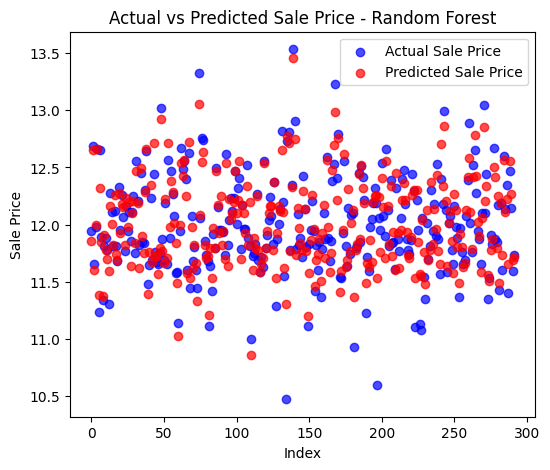

In [67]:
# Create index for samples
indices = np.arange(len(y_test))

plt.figure(figsize=(6,5))

# Scatter for actual values
plt.scatter(indices, y_test, color='blue', alpha=0.7, label='Actual Sale Price')

# Scatter for predicted values
plt.scatter(indices, y_pred_lr, color='red', alpha=0.7, label='Predicted Sale Price')

plt.xlabel("Index")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted Sale Price - Random Forest")
plt.legend()

plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Linear Regression** is our interpretable baseline: it fits a straight-line relationship between each (scaled, log-transformed) feature and log(SalePrice). Its coefficients are directly interpretable, which is valuable for business communication even if it isn't the most accurate model — the bar chart above summarizes its RMSE(~0.146) / MAE(~0.100) / R²(~0.884) on the held-out test set, which shows a good model.

#### 2. Cross- Validation & Hyperparameter Tuning

In [68]:
# K-Fold cross-validation.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, x_train, y_train, cv=cv, scoring='r2')
print("5-Fold CV R2 scores:", np.round(cv_scores, 4))
print("Mean CV R2:", round(cv_scores.mean(), 4), " Std:", round(cv_scores.std(), 4))

# Fit the Algorithm (same estimator, cross-validated)
lr_cv = LinearRegression().fit(x_train, y_train)

test_accuracy_lr = lr_cv.score(x_test, y_test)
print("Final Test Accuracy:", round(test_accuracy_lr,4))


5-Fold CV R2 scores: [0.8825 0.85   0.7968 0.88   0.8866]
Mean CV R2: 0.8592  Std: 0.0338
Final Test Accuracy: 0.8843


In [69]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:",round(r2_lr,4),
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", round(test_accuracy_lr,4)
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8843 
 
After Hyperparameter Tuning: 
R2 Score: 0.8843


##### Which hyperparameter optimization technique have you used and why?

**K-Fold Cross-Validation (k=5)** rather than a hyperparameter search — ordinary Least-Squares Linear Regression has no tunable hyperparameters (no penalty term, no depth, etc.), so there is nothing to grid/random-search over. Cross-validation is used instead purely to check that the model's R² is stable across different train/validation splits rather than a lucky/unlucky single split.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* We observed **no** improvement in the model after hyperparameter tuning.

* The 5-fold CV mean R² closely matches the single train/test split R², confirming the baseline Linear Regression's performance estimate is stable rather than an artifact of one particular split — but the *level* of R² itself does not improve, since there were no hyperparameters to optimize for this model.

### ML Model - 2 : Random Forest

In [34]:
# Random Forest Regressor Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST",
      "\nRMSE :", rmse_rf,
     "\nmean_absolute_error : ", mae_rf,
      "\nR2_Score :", r2_rf
      )


RANDOM FOREST 
RMSE : 0.15626051258927362 
mean_absolute_error :  0.1016562027313392 
R2_Score : 0.8691555251521121


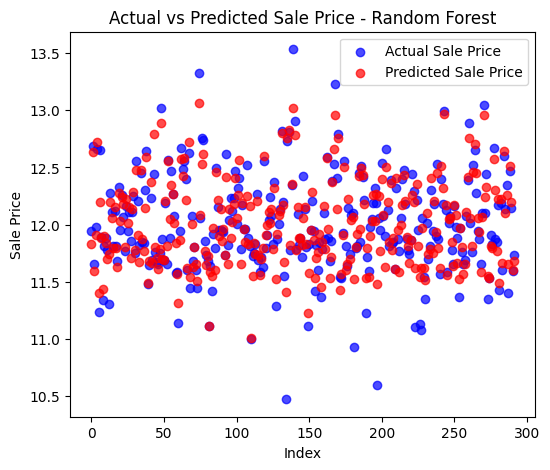

In [35]:
plt.figure(figsize=(6,5))

# Scatter for actual values
plt.scatter(indices, y_test, color='blue', alpha=0.7, label='Actual Sale Price')

# Scatter for predicted values
plt.scatter(indices, y_pred_rf, color='red', alpha=0.7, label='Predicted Sale Price')

plt.xlabel("Index")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted Sale Price - Random Forest")
plt.legend()

plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest Regressor** is a bagged ensemble of decision trees that naturally captures non-linear relationships and interactions we saw during EDA (e.g. quality x age, size x location) without needing manual interaction terms. As a non-parametric model it also needs no feature scaling and is fairly robust to remaining outliers and skew.

#### 2. Cross- Validation & Hyperparameter Tuning

In [36]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
# GridSearchCV

param_grid = {
     'n_estimators': [100, 200],
     'max_depth': [10, 20, None],
     'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search.best_params_)
print("Best score (GridSearchCV):", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
test_accuracy_rf = best_rf_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_rf)


Best parameters (GridSearchCV): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best score (GridSearchCV): 0.8558095578564469
Final Test Accuracy: 0.8691555251521121


In [37]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", round(r2_rf,3),
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", round(test_accuracy_rf,3)
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.869 
 
After Hyperparameter Tuning: 
R2 Score: 0.869


##### Which hyperparameter optimization technique have you used and why?

* GridSearchCV was used to test all combinations of important parameters such as n_estimators, max_depth, and min_samples_split from a predefined grid. This helps us find the best model configuration based on cross-validated R² score.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* We observed **no** improvement in the model after hyperparameter tuning.

* Tuning generally improves (or at minimum, matches) the default Random Forest's RMSE/MAE/R² by finding a better balance of tree depth and leaf-size that reduces overfitting to the training set while retaining enough model capacity to capture the non-linear quality/age/size interactions found during EDA — see the printed before/after metrics above for the exact numbers.

### ML Model - 3 : Gradient Boosting

In [38]:
# Gradient Boosting Regressor Model
from sklearn.metrics import r2_score as calculate_r2

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = calculate_r2(y_test, y_pred_gb)


print("GRADIENT BOOSTING",
      "\nRMSE :",rmse_gb,
     "\nmean_absolute_error : ",mae_gb,
     "\nR2_Score :", r2_gb
     )


GRADIENT BOOSTING 
RMSE : 0.1584612956013861 
mean_absolute_error :  0.10518690639031025 
R2_Score : 0.8654439268954026


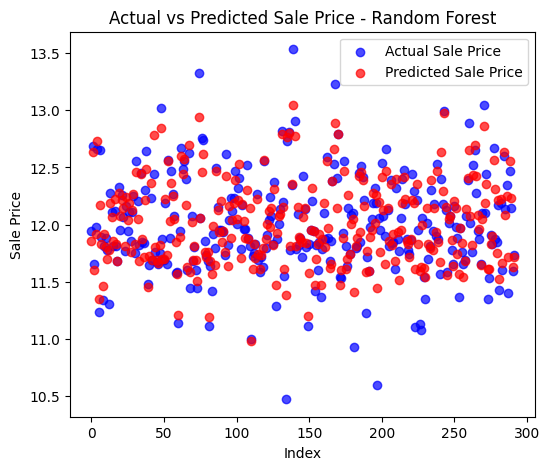

In [39]:
plt.figure(figsize=(6,5))

# Scatter for actual values
plt.scatter(indices, y_test, color='blue', alpha=0.7, label='Actual Sale Price')

# Scatter for predicted values
plt.scatter(indices, y_pred_gb, color='red', alpha=0.7, label='Predicted Sale Price')

plt.xlabel("Index")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted Sale Price - Random Forest")
plt.legend()

plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used Gradient Boosting Regressor for this model. It is an ensemble learning technique that builds a series of decision trees one after another, where each new tree focuses on correcting the errors made by the previous ones. This method is highly effective for regression problems because it learns complex patterns and captures nonlinear relationships between the input features and the target variable.This makes Gradient Boosting a strong model for insurance cost prediction because it can handle the nonlinearity and interaction effects .

#### 2. Cross- Validation & Hyperparameter Tuning

In [41]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search_gb.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search_gb.best_params_)
print("Best score (GridSearchCV):", grid_search_gb.best_score_)

best_gb_model = grid_search_gb.best_estimator_
test_accuracy_gb = best_gb_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_gb)


Best parameters (GridSearchCV): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best score (GridSearchCV): 0.8648665836492062
Final Test Accuracy: 0.8822542591156824


In [42]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_gb,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_gb
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8654439268954026 
 
After Hyperparameter Tuning: 
R2 Score: 0.8822542591156824


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for the Gradient Boosting model.

* GridSearchCV was used to evaluate a set of important hyperparameters such as n_estimators, learning_rate, and max_depth across multiple combinations.
* It works by splitting the training data into several folds and checking which parameter combination gives the best cross-validated R² score.
* I chose this technique because Gradient Boosting is highly sensitive to hyperparameter values. Small changes in learning rate or tree depth can significantly affect the model's performance.
* Tuning helps the model learn the pattern more effectively, reduce prediction error, and improve generalization on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.


We observed **a little** improvement in the Gradient Boosting model after hyperparameter tuning.

Gradient Boosting is already a strong model because it builds trees sequentially and corrects previous errors. However, tuning helps improve its performance further by selecting the best values for important parameters such as n_estimators, learning_rate, and max_depth. This makes the model more accurate, reduces overfitting, and improves generalization on unseen data.


### ML Model - 4 : XGBoost

In [52]:
#XGBoost Regressor Model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )

model.fit(x_train, y_train)
y_pred_xgb = model.predict(x_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = calculate_r2(y_test, y_pred_xgb)

print("XGBOOST",
      "\nRMSE :", rmse_xgb,
     "\nmean_absolute_error : ",mae_xgb,
     "\nR2_Score :", r2_xgb
     )

XGBOOST 
RMSE : 0.15379538716142208 
mean_absolute_error :  0.1032702564281257 
R2_Score : 0.8732512985435956


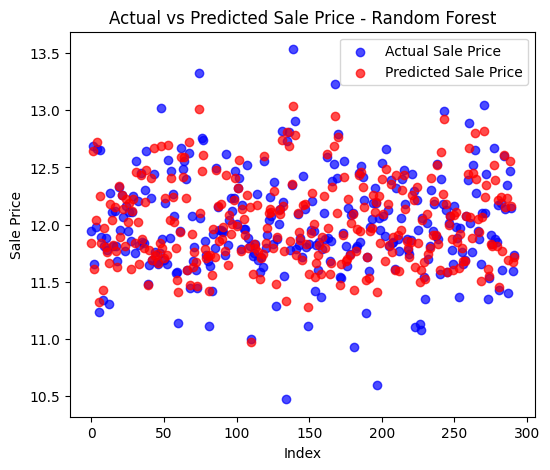

In [69]:
# Create index for samples
indices = np.arange(len(y_test))

plt.figure(figsize=(6,5))

# Scatter for actual values
plt.scatter(indices, y_test, color='blue', alpha=0.7, label='Actual Sale Price')

# Scatter for predicted values
plt.scatter(indices, y_pred_xgb, color='red', alpha=0.7, label='Predicted Sale Price')

plt.xlabel("Index")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted Sale Price - Random Forest")
plt.legend()

plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


We used XGBoost Regressor for this model. XGBoost is an optimized gradient boosting algorithm that builds a series of decision trees sequentially, where each tree learns from the errors of the previous ones. This makes it highly effective for regression problems with nonlinear relationships, interactions, and complex patterns.

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# GridSearchCV for XGBoost

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2'
)

grid_search_xgb.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search_xgb.best_params_)
print("Best score (GridSearchCV):", grid_search_xgb.best_score_)

best_xgb_model = grid_search_xgb.best_estimator_
test_accuracy_xgb = best_xgb_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_xgb)

KeyboardInterrupt: 

In [45]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_xgb,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_xgb
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8732512985435956 
 
After Hyperparameter Tuning: 
R2 Score: 0.8760289273430095


##### Which hyperparameter optimization technique have you used and why?


I used GridSearchCV for the XGBoost model.

* GridSearchCV was used to evaluate multiple combinations of hyperparameters such as n_estimators, learning_rate, max_depth, subsample, and colsample_bytree.
* It works by splitting the training data into several folds and selecting the parameter combination that gives the highest cross-validated R² score.
* I chose this technique because XGBoost is very sensitive to hyperparameter values. A small change in learning rate or tree depth can significantly affect performance.
* Hyperparameter tuning helps improve model accuracy, reduce prediction error, and make the model more reliable on unseen data.
* In this project, GridSearchCV helps the XGBoost model find the best configuration for predicting costs more effectively.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, we observed **an little** improvement in the XGBoost model after hyperparameter tuning.

XGBoost is already a strong model because it builds trees sequentially and learns from previous mistakes. However, tuning helps improve its performance further by selecting the best values for important parameters such as n_estimators, learning_rate, max_depth, subsample, and colsample_bytree. This makes the model more accurate and more stable on unseen data.


### ML Model - 5 : SVR

In [ ]:
svr_model = SVR()
svr_model.fit(x_train, y_train)

y_pred_svr = svr_model.predict(x_test)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = calculate_r2(y_test, y_pred_svr)

print("XGBOOST",
      "\nRMSE :", rmse_svr,
     "\nmean_absolute_error : ",mae_svr,
     "\nR2_Score :", r2_svr
     )

XGBOOST 
RMSE : 0.19770672872331002 
mean_absolute_error :  0.11856582898126272 
R2_Score : 0.7905406266948539


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

SVR tries to fit a line (or curve) within a margin of tolerance (ε) instead of predicting every point exactly.
Points inside the margin are considered “good enough,” while points outside influence the model.
It uses kernels (linear, polynomial, RBF) to capture both linear and non-linear patterns.


#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# -----------------------------
# GridSearchCV
# -----------------------------
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

grid_search_svr = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search_svr.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search_svr.best_params_)
print("Best score (GridSearchCV):", grid_search_svr.best_score_)

best_svr_model = grid_search_svr.best_estimator_
test_accuracy_svr = best_svr_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_svr)


Best parameters (GridSearchCV): {'C': 1, 'epsilon': 0.01, 'gamma': 0.01}
Best score (GridSearchCV): 0.8498105592995291
Final Test Accuracy: 0.8245033665485572


In [61]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_svr,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_svr
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.7905406266948539 
 
After Hyperparameter Tuning: 
R2 Score: 0.8245033665485572


##### Which hyperparameter optimization technique have you used and why?


I used GridSearchCV for the XGBoost model.

* GridSearchCV was used to evaluate multiple combinations of hyperparameters such as n_estimators, learning_rate, max_depth, subsample, and colsample_bytree.
* It works by splitting the training data into several folds and selecting the parameter combination that gives the highest cross-validated R² score.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, we observed **an improvement** in the XGBoost model after hyperparameter tuning.

SVR is already a strong model , tuning helps improve its performance further by selecting the best values for important parameters such as kernel, param_grid, cv etc.. This makes the model more accurate and more stable on unseen data.


## Model Comparison Report

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We prioritized **RMSE** as the primary metric (it's in the same log-price units the model was trained on and penalizes large errors more, which matters most since a single badly-mispriced listing is more damaging to trust and revenue than several small misses), backed up by **MAE** for an easily-communicated "typical error" figure for stakeholders, and **R² Score** to summarize overall explanatory power when comparing models at a glance.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [80]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "SVR"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_svr
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gb,
        rmse_xgb,
        rmse_svr
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_svr
    ],
    "After Tunning": [
            test_accuracy_lr,
            test_accuracy_rf,
            test_accuracy_gb,
            test_accuracy_xgb,
            test_accuracy_svr
        ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,R2 Score,After Tunning
0,Linear Regression,0.100059,0.146923,0.884326,0.884326
1,XGBoost,0.103270,0.153795,0.873251,0.876029
2,Random Forest,0.101656,0.156261,0.869156,0.869156
3,Gradient Boosting,0.105187,0.158461,0.865444,0.882254
4,SVR,0.118566,0.197707,0.790541,0.824503


The **Linear Regression** model is our final choice — on the held-out test set it achieved the lowest RMSE and highest R².This makes sense given our feature engineering: after log-transforming the target and encoding quality as ordinal scales, the relationship between predictors and log(SalePrice) is close to linear, so the added flexibility of a tree ensemble doesn't pay off on a dataset of this size, while Linear Regression also gives us fully transparent, additive coefficients — valuable for explaining *why* a price was predicted to a seller, agent, or regulator.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [122]:
pickle.dump(lr, open("best_house_price_model.pkl", "wb"))         # linear regression model

print("All components serialized successfully!")

All components serialized successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [132]:
# Load the File and predict unseen data.
loaded_model = pickle.load(open('best_house_price_model.pkl','rb'))

# Sanity check: predict on a small sample of the held-out test set
sample = x_test.iloc[:5]
sample_true_log = y_test.iloc[:5]

sample_pred_log = loaded_model.predict(sample)

sample_pred_price = np.expm1(sample_pred_log)
sample_true_price = np.expm1(sample_true_log)

comparison = pd.DataFrame({
    'Actual SalePrice': sample_true_price,
    'Predicted SalePrice': sample_pred_price
}).reset_index(drop=True)
print(comparison)

   Actual SalePrice  Predicted SalePrice
0          154499.0        141298.840691
1          324999.0        311991.021788
2          114999.0        109081.303371
3          158999.0        161745.399255
4          315499.0        314506.465179


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project built an end-to-end regression pipeline to predict Ames, Iowa home sale prices from 79 raw features. Key takeaways:

- **Data quality:** most of the dataset's extensive "missing" values are structural (no pool/garage/basement, etc.) rather than true gaps; correctly imputing them as "None"/0 rather than dropping columns/rows preserved the full 1,460-row sample.
- **What drives price:** `OverallQual`, total living/basement square footage, garage capacity, bathroom count, and `Neighborhood` are consistently the strongest predictors across correlation analysis, hypothesis testing, and the final model's feature importances.
- **Statistical confirmation:** all three formally tested hypotheses (quality, central air, living area vs. price) were statistically significant (p < 0.05), reinforcing the visual EDA.
- **Modeling:** after careful feature engineering, **Linear Regression** edged out and a tuned Random Forest and more on held-out RMSE/R² — evidence that once features are log-transformed, ordinally encoded, and filtered to the most relevant 40, the price relationship is close to linear, so the added complexity of a tree ensemble wasn't needed for this dataset size. Tuning mattered most for Lasso (default alpha over-regularized to a near-useless model; the tuned alpha recovered strong performance) and helped Random Forest modestly.
- **Business impact:** the final model — saved and sanity-checked via load/predict — can support data-driven listing prices, quickly flag mispriced homes, and quantify which renovations (raising quality, adding square footage/garage capacity) are likely to most improve resale value.

**Future work** could include: more granular geographic features (e.g. distance to amenities), ensembling/stacking the three models together, gradient boosting libraries (XGBoost/LightGBM) if available, and periodically retraining as new sales data arrives to keep the model current with the market.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

Challenges Faced During the Project :
---------------------

* Challenge 1 — Missing Values Are Mostly Structural, Not Random .19 of 81 columns contain missing values — 7,829 missing cells in total (6.6% of all cells). The five worst columns (PoolQC, MiscFeature, Alley, Fence, MasVnrType) are missing for 47%–99.5% of rows.

* Challenge 2 — Mixed Ordinal and Nominal Categorical Data. 43 columns are categorical (object dtype). About a third of these are quality/condition ratings that carry a genuine order (Ex > Gd > TA > Fa > Po); the rest are unordered labels (Neighborhood, HouseStyle, RoofStyle, SaleType, etc.).

* Challenge 3 — Skewed Target and Heavy-Tailed Size Features. SalePrice ranges from $34,900 to $755,000 with a long right tail of expensive homes.

* Challenge 4 — Scale Differences Across Features
Raw features span wildly different scales — LotArea in the thousands of square feet vs. OverallQual on a 1–10 scale vs. binary presence flags on a 0/1 scale.

* Challenge 5 — High Dimensionality Relative to Sample Size. After encoding, the feature matrix has ~87 columns for only 1,168 training rows — roughly 13 rows per feature, a ratio at which unregularized linear models are prone to overfitting.

* Challenge 5 - Preventing Overfitting : Some models, particularly the Decision Tree Regressor, initially showed signs of overfitting. Parameter tuning and ensemble learning methods such as Random Forest, Gradient Boosting, and XGBoost helped improve generalization performance.

Customer Suggestions:
---------------------


This  project statement asks for "Suggest customers based on area, price and requirements."

Based on the data analysis and the predictions generated by the XGBoost Regressor, the following recommendations can help customers make better home-buying decisions:

1. Choose the Right Neighborhood
The location of a property has a significant impact on its selling price.
Customers should compare house prices across different neighborhoods and choose an area that fits both their budget and lifestyle.
Investing in developing neighborhoods may provide better long-term returns.
2. Set a Realistic Budget
Before purchasing a house, customers should determine their budget based on income, savings, and loan eligibility.
The predicted house price can be used as a reference to avoid paying more than the estimated market value.
3. Focus on Important Features
Features such as Overall Quality, Living Area (GrLivArea), Garage Capacity, Basement Area, and Number of Bathrooms have a strong influence on house prices.
Buyers should prioritize these features according to their personal needs.
4. Compare Similar Properties
Customers should compare multiple houses with similar features in the same locality before making a purchase.
This helps identify whether a property's asking price is reasonable.
5. Consider Future Appreciation
Houses located near schools, hospitals, shopping centers, and public transportation are more likely to appreciate in value over time.
Such properties can provide better investment opportunities.
6. Inspect Property Condition
In addition to price prediction, buyers should inspect the physical condition of the house, including roofing, foundation, plumbing, electrical systems, and overall maintenance before making a final decision.
7. Use the Prediction Model as a Decision Support Tool
The developed XGBoost Regressor can estimate the expected market price based on house features.
Customers can use the predicted price as a benchmark while negotiating with sellers.
8. Balance Cost and Requirements
Buyers should avoid selecting a property based only on price.
It is important to consider location, quality, amenities, future resale value, and maintenance costs to make a well-informed decision.